In [2]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF

from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

from herculens.MassModel.mass_model_multiplane import MPMassModel
from herculens.LightModel.light_model_multiplane import MPLightModel
from herculens.LensImage.lens_image_multiplane import MPLensImage

/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


set up the coordinate grid

In [3]:
nx, ny = (101, 101) # number of pixels per side
pix_scale = 0.05 # physical width of pixel (arcsec)

In [4]:
# what is the physical coordinate of the (0, 0) corner pixel?
half_size_x = nx*pix_scale/2
half_size_y = ny*pix_scale/2
ra_at_xy_0 = -half_size_x + pix_scale/2
dec_at_xy_0 = -half_size_y + pix_scale/2

transform_pix2angle = pix_scale*np.eye(2)
kwargs_pixel = {
    'nx': nx,
    'ny': ny,
    'ra_at_xy_0': ra_at_xy_0,
    'dec_at_xy_0': dec_at_xy_0,
    'transform_pix2angle': transform_pix2angle
}

# herculens' pixel grid class handles everything
pixel_grid = PixelGrid(**kwargs_pixel)

# useful things we might need from it
xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent
x_grid, y_grid = np.meshgrid(x_axis, y_axis)   

set up a telescope

In [5]:
exposure_time = 600 
background_rms = 0.01
fwhm = 0.1

noise = Noise(nx, ny, background_rms=background_rms, exposure_time=exposure_time)
psf = PSF(psf_type='GAUSSIAN', fwhm=fwhm, pixel_size=pix_scale)

set up the lens

In [6]:
# what's included

from herculens.MassModel.mass_model_base import SUPPORTED_MODELS as available_mass_models
from herculens.LightModel.light_model_base import SUPPORTED_MODELS as available_light_models
print(f'available mass models : {available_mass_models}')
print(f'available light models : {available_light_models}')

available mass models : ['EPL', 'NIE', 'SIE', 'SIS', 'DPIE', 'PIEMD', 'GAUSSIAN', 'POINT_MASS', 'SHEAR', 'SHEAR_GAMMA_PSI', 'MULTIPOLE', 'PIXELATED', 'PIXELATED_DIRAC', 'PIXELATED_FIXED']
available light models : ['SERSIC', 'SERSIC_ELLIPSE', 'SERSIC_SUPERELLIPSE', 'GAUSSIAN', 'GAUSSIAN_ELLIPSE', 'MULTIPOLE', 'PIXELATED', 'UNIFORM', 'SHAPELETS']


In [7]:
lens_mass_model = MassModel(['EPL', 'SHEAR']) # add deflection angles together: elliptical power law with external shear
source1_mass_model = MassModel(['EPL']) 

lens_light_model = LightModel(['SERSIC_ELLIPSE']) # elliptical sersic profile
source1_light_model = LightModel(['SERSIC_ELLIPSE']) 
source2_light_model = LightModel(['SERSIC_ELLIPSE']) 

In [8]:
mpmass_model = MPMassModel([lens_mass_model, source1_mass_model])
mplight_model = MPLightModel([lens_light_model, source1_light_model, source2_light_model])

mass model

In [9]:
lens_EPL_kwargs = {
    'theta_E': 1.5,
    'gamma': 2.05,
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': 0.0,
    'gamma2': -0.03,
    'ra_0': lens_EPL_kwargs['center_x'],
    'dec_0': lens_EPL_kwargs['center_y'],
}

source1_EPL_kwargs = {
    'theta_E': 0.5,
    'gamma': 2.0,
    'e1': 0.0,
    'e2': 0.0,
    'center_x': 0.0,
    'center_y': 0.0
}

lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]
source1_mass_kwargs = [lens_EPL_kwargs]

mplens_mass_kwargs = [lens_mass_kwargs, source1_mass_kwargs]

# convergence
lens_kappa_wrtlens, lens_kappa_wrts1, lens_kappa_wrts2 = mpmass_model.kappa(x=x_grid, y=y_grid, kwargs=mplens_mass_kwargs, eta_flat=1.2)

# shear
gamma1, gamma2 = mpmass_model.gamma(x=x_grid, y=y_grid, kwargs=mplens_mass_kwargs, eta_flat=1.2)
lens_gamma_1_wrtlens, lens_gamma_1_wrts1, lens_gamma_1_wrts2 = gamma1
lens_gamma_2_wrtlens, lens_gamma_2_wrts1, lens_gamma_2_wrts2 = gamma2

# magnification
lens_mu_wrtlens, lens_mu_wrts1, lens_mu_wrts2 = mpmass_model.inverse_magnification(x=x_grid, y=y_grid, kwargs=mplens_mass_kwargs, eta_flat=1.2)

# # deflection angle
# lens_alpha = lens_mass_model.alpha(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
# lens_alpha_x, lens_alpha_y = lens_alpha

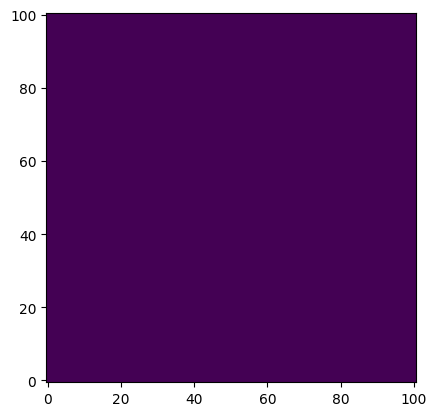

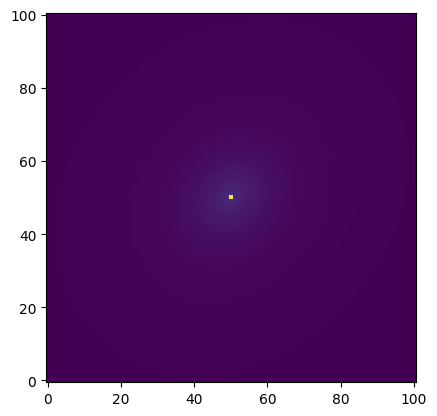

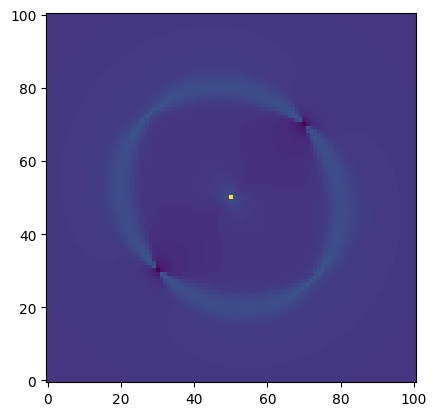

In [25]:
plt.imshow(lens_kappa_wrtlens, norm='symlog')
plt.show()

plt.imshow(lens_kappa_wrts1, norm='symlog')
plt.show()

plt.imshow(lens_kappa_wrts2, norm='symlog')
plt.show()

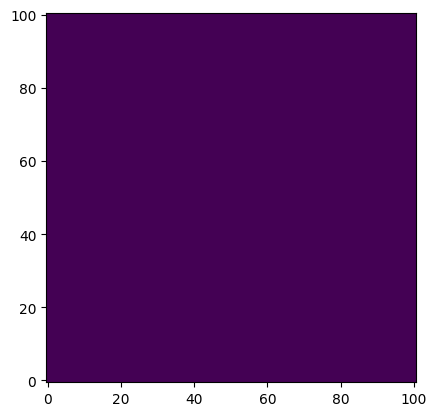

In [11]:
plt.imshow(1/lens_mu_wrtlens)
plt.show()

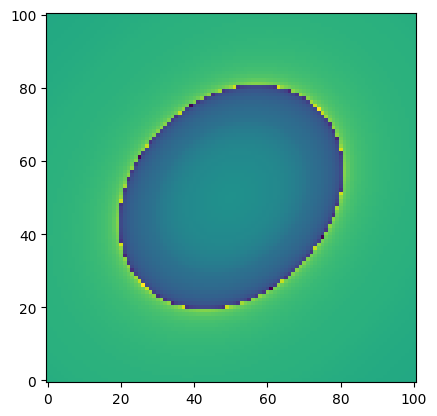

In [12]:
plt.imshow(1/lens_mu_wrts1, norm='symlog')
plt.show()

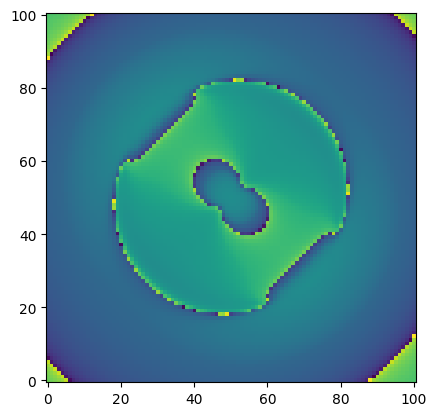

In [13]:
plt.imshow(1/lens_mu_wrts2, norm='symlog')
plt.show()

light model

In [14]:
lens_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.5,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}

lens_light_kwargs = [lens_sersic_kwargs]

In [15]:
source1_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.1,
    'n_sersic': 1.0, # n=1: exponential profile
    'e1': 0.0,
    'e2': 0.0,
    'center_x': 0.0,
    'center_y': 0.0
}

source1_light_kwargs = [source1_sersic_kwargs]

In [16]:
source2_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.02,
    'n_sersic': 1.0, # n=1: exponential profile
    'e1': 0.0,
    'e2': 0.0,
    'center_x': 0.0,
    'center_y': 0.0
}

source2_light_kwargs = [source2_sersic_kwargs]

mplight_kwargs = [lens_light_kwargs, source1_light_kwargs, source2_light_kwargs]

In [17]:
# lens_light_prof = lens_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=lens_light_kwargs)
# source_light_prof = source1_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=source1_light_kwargs) # bare in mind that this is computed from image plane coordinates


In [18]:
# # what do the lens and source look like?

# plt.figure(figsize=(15, 5))

# plt.subplot(121)
# plt.imshow(lens_light_prof, origin='lower', cmap='PuOr_r', norm='log', extent=extent)
# plt.colorbar()
# plt.title('lens light')

# plt.subplot(122)
# plt.imshow(source_light_prof, origin='lower', cmap='PuOr_r',  norm='log', extent=extent)
# plt.colorbar()
# plt.title('source light')

fun stuff

In [19]:
# handles stuff that needs ray tracing
lens_image = MPLensImage(
    grid_class=pixel_grid,
    psf_class=psf,
    noise_class=noise,
    mass_model_class=mpmass_model,
    light_model_class=mplight_model
)

lens_image.model?

Signature:
lens_image.model(
    eta_flat=None,
    kwargs_mass=None,
    kwargs_light=None,
    supersampled=False,
    unconvolved=False,
    k_mass=None,
    k_light=None,
    k_planes=None,
    return_pixel_scale=False,
)
Docstring:
Create the 2D model image from the parameter values.  Note: due to JIT compilation,
the first call to this method will be slower.

Parameters
----------
eta_flat : jax.numpy array
    upper triangular elements of eta matrix, values defined as
    eta_ij = D_ij D_i+1 / D_j D_ii+1 where D_ij is the angular diameter
    distance between redshifts i and j. Only include values where
    j > i+1. This convention implies that all einstein radii are defined
    with respect to the **next** mass plane back (**not** the last plane in
    the stack).
    For more details, see comments in the Pull Request #37:
    https://github.com/Herculens/herculens/pull/37#issuecomment-2343179184
kwargs_mass : list of list
    List of lists of parameter dictionaries of lens mas

In [20]:
model_image = lens_image.model(unconvolved=True, kwargs_mass=mplens_mass_kwargs, kwargs_light=mplight_kwargs, eta_flat=jnp.array([1.2]))

Text(0.5, 1.0, 'a model lens')

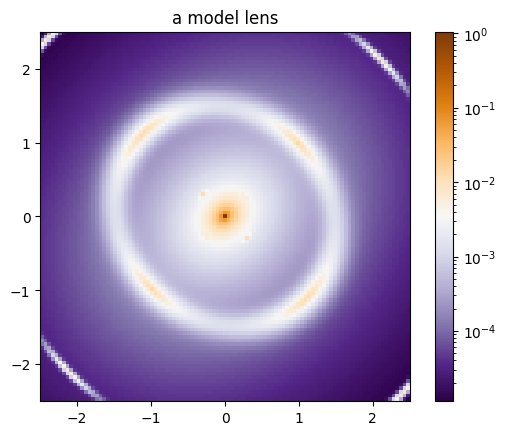

In [21]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')

In [22]:
model_image = lens_image.model(unconvolved=False, kwargs_lens=lens_mass_kwargs, kwargs_source=source_light_kwargs, kwargs_lens_light=lens_light_kwargs)

NameError: name 'source_light_kwargs' is not defined

Text(0.5, 1.0, 'a model lens')

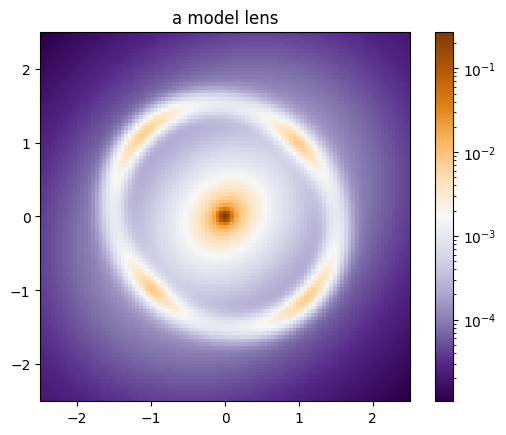

In [ ]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')

In [ ]:
model_image = lens_image.simulation(unconvolved=False, kwargs_lens=lens_mass_kwargs, kwargs_source=source_light_kwargs, kwargs_lens_light=lens_light_kwargs)

Text(0.5, 1.0, 'a model lens')

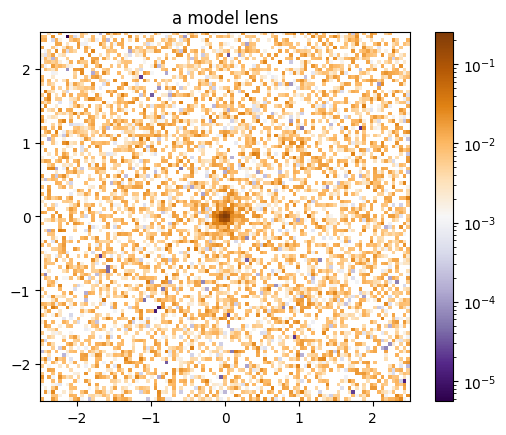

In [ ]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')